# Register FA-images to MNI for atlases in this standard space

1. FA --> T1
2. T1 --> MNI (already done by fmriprep?)
sub-01_ses-1_from-T1w_to-MNI152NLin2009cAsym_mode-image_xfm.h5


3. FA --> T1 --> MNI

DWI-Atlas in standard space?

In [4]:
import ants # pip install antspyx is neccessary1
import subprocess
import os.path as op
import nibabel as nib

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'


####  copy necessary T1s 

base_target_dir=/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives

for sub in $(seq -w 1 66); do 
mkdir 
cp /mnt_03/ds-dnumrisk/derivatives/fmriprep/sub-${sub}/ses-1/anat/sub-${sub}_ses-1_desc-preproc_T1w.nii.gz ${base_target_dir}/fmriprep/sub-${sub}/ses-1/anat/sub-${sub}_ses-1_desc-preproc_T1w.nii.gz
cp /mnt_03/ds-dnumrisk/derivatives/fmriprep/sub-${sub}/ses-1/anat/sub-${sub}_ses-1_desc-brain_mask.nii.gz ${base_target_dir}/fmriprep/sub-${sub}/ses-1/anat/sub-${sub}_ses-1_desc-brain_mask.nii.gz
cp /mnt_03/ds-dnumrisk/derivatives/fmriprep/sub-${sub}/ses-1/anat/sub-${sub}_ses-1_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz ${base_target_dir}/fmriprep/sub-${sub}/ses-1/anat/sub-${sub}_ses-1_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz
cp /mnt_03/ds-dnumrisk/derivatives/fmriprep/sub-${sub}/ses-1/anat/sub-${sub}_ses-1_from-T1w_to-MNI152NLin2009cAsym_mode-image_xfm.h5 ${base_target_dir}/fmriprep/sub-${sub}/ses-1/anat/sub-${sub}_ses-1_from-T1w_to-MNI152NLin2009cAsym_mode-image_xfm.h5

; done

In [ ]:
# on sciencecloud ipython
bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'

import os
import os.path as op

for sub in os.listdir(op.join(bids_folder,'derivatives','fmriprep')):
    os.makedirs(op.join(bids_folder,'derivatives','fmriprep',sub,'ses-1','anat'),exist_ok=True)


In [ ]:
import os

sub = '02'

source_dir = op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{sub}', 'ses-1/anat')
os.makedirs(source_dir)

# copy on sciencecloud !
# cp /mnt_03/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/anat/sub-01_ses-1_desc-preproc_T1w.nii.gz /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/anat/sub-01_ses-1_desc-preproc_T1w.nii.gz

### Loop

In [31]:
sub = '03'

In [32]:
anat_dir = op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{sub}', 'ses-1/anat')
dwi_dir = op.join(bids_folder, 'derivatives', 'dwi_preproc', f'sub-{sub}')

# T1 brain extraction
fn_anat = op.join(anat_dir, f'sub-{sub}_ses-1_desc-preproc_T1w.nii.gz')
t1 = nib.load(fn_anat).get_fdata()
fn_anat_mask = op.join(anat_dir, f'sub-{sub}_ses-1_desc-brain_mask.nii.gz')
mask = nib.load(fn_anat_mask).get_fdata()
t1_brain = t1 * mask
fn_out = op.join(anat_dir, f'sub-{sub}_ses-1_desc-preproc_T1w_brain.nii.gz')
nib.save(nib.Nifti1Image(t1_brain, nib.load(fn_anat).affine), fn_out)

# transform FA to T1
fixed =  ants.image_read(op.join(anat_dir, f'sub-{sub}_ses-1_desc-preproc_T1w_brain.nii.gz'))
moving = ants.image_read(op.join(dwi_dir, f'sub-{sub}_dtifit_res_FA.nii.gz'))

reg = ants.registration(fixed = fixed, moving = moving, type_of_transform = "SyN")
fa_in_t1 = reg["warpedmovout"]
fa_in_t1.to_filename(op.join(dwi_dir,'fa_in_T1.nii.gz'))

# transform FA_in_T1 to MNI (T1 to MNI done by fMRIPrep)
fa_t1 = ants.image_read(op.join(dwi_dir,'fa_in_T1.nii.gz'))
anat_dir = op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{sub}', 'ses-1/anat')
mni_ref = ants.image_read(op.join(anat_dir, f'sub-{sub}_ses-1_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz'))

fa_in_mni = ants.apply_transforms(
    fixed=mni_ref,
    moving=fa_t1,
    transformlist=[op.join(anat_dir,f'sub-{sub}_ses-1_from-T1w_to-MNI152NLin2009cAsym_mode-image_xfm.h5')]# Apply fMRIPrep's transform
)
fa_in_mni.to_filename(op.join(dwi_dir,"fa_in_MNI.nii.gz"))

In [ ]:
subList = [f'{i:02d}' for i in range(1, 67)]

for sub in subList:
    anat_dir = op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{sub}', 'ses-1/anat')
    dwi_dir = op.join(bids_folder, 'derivatives', 'dwi_preproc', f'sub-{sub}')

    # T1 brain extraction
    fn_anat = op.join(anat_dir, f'sub-{sub}_ses-1_desc-preproc_T1w.nii.gz')
    t1 = nib.load(fn_anat).get_fdata()
    fn_anat_mask = op.join(anat_dir, f'sub-{sub}_ses-1_desc-brain_mask.nii.gz')
    mask = nib.load(fn_anat_mask).get_fdata()
    t1_brain = t1 * mask
    fn_out = op.join(anat_dir, f'sub-{sub}_ses-1_desc-preproc_T1w_brain.nii.gz')
    nib.save(nib.Nifti1Image(t1_brain, nib.load(fn_anat).affine), fn_out)

    # transform FA to T1
    fixed =  ants.image_read(op.join(anat_dir, f'sub-{sub}_ses-1_desc-preproc_T1w_brain.nii.gz'))
    moving = ants.image_read(op.join(dwi_dir, f'sub-{sub}_dtifit_res_FA.nii.gz'))

    reg = ants.registration(fixed = fixed, moving = moving, type_of_transform = "SyN")
    fa_in_t1 = reg["warpedmovout"]
    fa_in_t1.to_filename(op.join(dwi_dir,f'sub-{sub}_FA_in_T1.nii.gz'))

    # transform FA_in_T1 to MNI (T1 to MNI done by fMRIPrep)
    fa_t1 = ants.image_read(op.join(dwi_dir,f'sub-{sub}_FA_in_T1.nii.gz'))
    anat_dir = op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{sub}', 'ses-1/anat')
    mni_ref = ants.image_read(op.join(anat_dir, f'sub-{sub}_ses-1_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz'))

    fa_in_mni = ants.apply_transforms(
        fixed=mni_ref,
        moving=fa_t1,
        transformlist=[op.join(anat_dir,f'sub-{sub}_ses-1_from-T1w_to-MNI152NLin2009cAsym_mode-image_xfm.h5')]# Apply fMRIPrep's transform
    )
    fa_in_mni.to_filename(op.join(dwi_dir,f'sub-{sub}_FA_in_MNI.nii.gz'))
# 37 min total

### Singel Steps

In [30]:
import nibabel as nib

anat_dir = op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{sub}', 'ses-1/anat')
fn_anat = op.join(anat_dir, f'sub-{sub}_ses-1_desc-preproc_T1w.nii.gz')
t1 = nib.load(fn_anat).get_fdata()

fn_anat_mask = op.join(anat_dir, f'sub-{sub}_ses-1_desc-brain_mask.nii.gz')
mask = nib.load(fn_anat_mask).get_fdata()
t1_brain = t1 * mask

fn_out = op.join(anat_dir, f'sub-{sub}_ses-1_desc-preproc_T1w_brain.nii.gz')
nib.save(nib.Nifti1Image(t1_brain, nib.load(fn_anat).affine), fn_out)

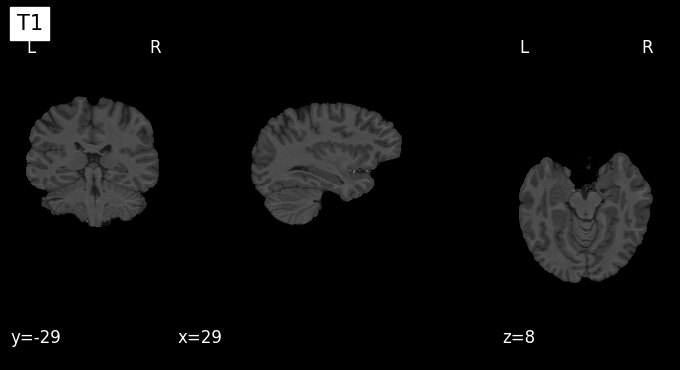

In [19]:
from nilearn import plotting

plotting.plot_anat(fn_out, title='T1', draw_cross=False)

In [ ]:
anat_dir = op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{sub}', 'ses-1/anat')
fn_out = op.join(anat_dir, f'sub-{sub}_ses-1_desc-preproc_T1w_brain.nii.gz')

fixed =  ants.image_read(fn_out) 

source_dir = op.join(bids_folder, 'derivatives', 'dwi_preproc', f'sub-{sub}')
moving = ants.image_read(op.join(source_dir, f'sub-{sub}_dtifit_res_FA.nii.gz'))

reg = ants.registration(fixed = fixed, moving = moving, type_of_transform = "SyN")
fa_in_t1 = reg["warpedmovout"]
fa_in_t1.to_filename(op.join(source_dir,'fa_in_T1.nii.gz'))

In [32]:
fa_in_t1 = reg["warpedmovout"]
fa_in_t1.to_filename(op.join(source_dir,'fa_in_T1.nii.gz'))

In [34]:
fa_t1 = ants.image_read(op.join(source_dir,'fa_in_T1.nii.gz'))

anat_dir = op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{sub}', 'ses-1/anat')
mni_ref = ants.image_read(op.join(anat_dir, f'sub-{sub}_ses-1_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz'))

# Apply fMRIPrep's transform
fa_in_mni = ants.apply_transforms(
    fixed=mni_ref,
    moving=fa_t1,
    transformlist=[op.join(anat_dir,f'sub-{sub}_ses-1_from-T1w_to-MNI152NLin2009cAsym_mode-image_xfm.h5')]
)
fa_in_mni.to_filename(op.join(source_dir,"fa_in_MNI.nii.gz"))


## extract tract-ROIs with atlas and get mean FA-ROI values

1. resample !
The JHU atlases (from FSL or nilearn) are in MNI152 linear (FSL) 1mm space with shape (182, 218, 182)
Your FA map (fa_in_MNI) is in MNI152NLin2009cAsym (fMRIPrep's template) with shape (193, 229, 193)
So they are in different MNI templates — visually similar, but not directly voxel-aligned. You must resample one to the other.

2. 
? - label - name mapping ? 
got labels via:
wget http://neurovault.org/media/images/264/JHU-ICBM-labels-1mm.xml

In [ ]:
from nilearn import image

# resample atlas to new MNI space 
sub = '01' # Just use any subjects MNI space T1w image as a standard
source_dir = op.join(bids_folder, 'derivatives', 'dwi_preproc', f'sub-{sub}')
source_im = nib.load('/home/ubuntu/fsl/data/atlases/JHU/JHU-ICBM-labels-1mm.nii.gz')

target_im = nib.load(op.join(source_dir,"fa_in_MNI.nii.gz"))
resamp_im = image.resample_to_img(source_im, target_im, interpolation='nearest')
resamp_im.to_filename('/home/ubuntu/fsl/data/atlases/JHU/JHU-ICBM-labels-1mm_MNI152NLin2009cAsym.nii.gz')

<function nilearn.image.resampling.resample_to_img(source_img, target_img, interpolation='continuous', copy=True, order='F', clip=False, fill_value=0, force_resample=False)>

In [5]:
sub = '01'
source_dir = op.join(bids_folder, 'derivatives', 'dwi_preproc', f'sub-{sub}')

fa_in_mni = nib.load(op.join(source_dir,"fa_in_MNI.nii.gz")).get_fdata()
fa_in_mni.shape

(193, 229, 193)

In [ ]:
import numpy as np
atlas_data = nib.load('/home/ubuntu/fsl/data/atlases/JHU/JHU-ICBM-labels-1mm_MNI152NLin2009cAsym.nii.gz').get_fdata()
print(atlas_data.shape)
np.unique(atlas_data)


(193, 229, 193)


array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.])

In [24]:
# Extract FA per tract
labels = np.unique(atlas_data)
results = {}

for i, label in enumerate(labels):
    mask = atlas_data == label
    fa_vals = fa_in_mni[mask]
    fa_vals = fa_vals[~np.isnan(fa_vals)]
    if len(fa_vals) > 0:
        results[label] = np.mean(fa_vals)

# View results
for tract, mean_fa in results.items():
    print(f"{tract}: {mean_fa:.3f}")

0.0: 0.042
1.0: 0.416
2.0: 0.482
3.0: 0.426
4.0: 0.481
5.0: 0.532
6.0: 0.364
7.0: 0.418
8.0: 0.408
9.0: 0.384
10.0: 0.425
11.0: 0.314
12.0: 0.300
13.0: 0.409
14.0: 0.321
15.0: 0.494
16.0: 0.551
17.0: 0.524
18.0: 0.437
19.0: 0.548
20.0: 0.563
21.0: 0.479
22.0: 0.535
23.0: 0.425
24.0: 0.417
25.0: 0.445
26.0: 0.447
27.0: 0.478
28.0: 0.435
29.0: 0.539
30.0: 0.440
31.0: 0.486
32.0: 0.395
33.0: 0.338
34.0: 0.318
35.0: 0.379
36.0: 0.349
37.0: 0.334
38.0: 0.271
39.0: 0.300
40.0: 0.331
41.0: 0.446
42.0: 0.425
43.0: 0.450
44.0: 0.354
45.0: 0.330
46.0: 0.370
47.0: 0.362
48.0: 0.287
49.0: 0.217
50.0: 0.152


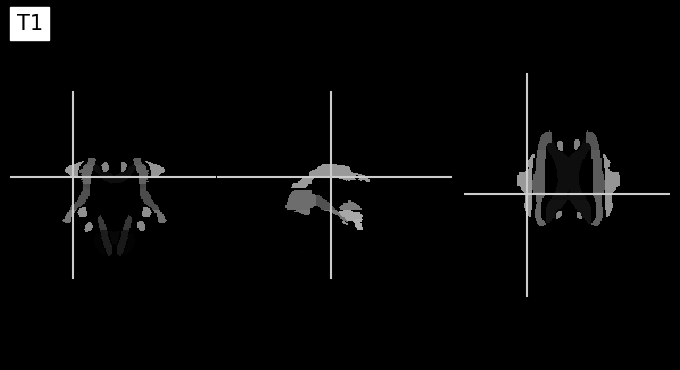

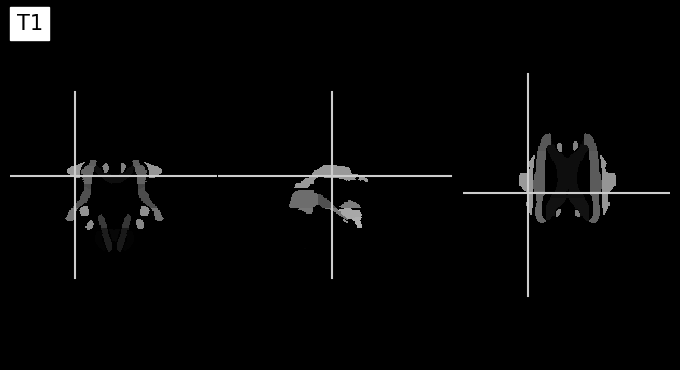

In [22]:
from nilearn import plotting

im = nib.load('/home/ubuntu/fsl/data/atlases/JHU/JHU-ICBM-labels-1mm.nii.gz') # _MNI152NLin2009cAsym
plotting.plot_anat(im, title='T1', draw_cross=True, 
                   display_mode='ortho', #cut_coords=[36, -27, 66],
                   annotate=False, black_bg=True)

im = nib.load('/home/ubuntu/fsl/data/atlases/JHU/JHU-ICBM-labels-1mm_MNI152NLin2009cAsym.nii.gz') # 
plotting.plot_anat(im, title='T1', draw_cross=True, 
                   display_mode='ortho', #cut_coords=[36, -27, 66],
                   annotate=False, black_bg=True)
# WM- so looks different 